# 3D pipeline: zero-shot FM rotation search
This notebook evaluates a 2D-trained rotation FM on the Ganis-Kievit 3D stimuli
(preprocessed in `data/train_pairs.npy` and `data/test_balanced.npy`).

We treat the FM as a rotation operator and perform a deterministic angle search.
No retraining. Metrics are computed on the balanced test set.


In [17]:
%cd /Users/masha/Documents/visual-reasoning

import os
import math
import random
from typing import List, Tuple, Dict, Any

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import timm

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt


/Users/masha/Documents/visual-reasoning


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_PATH = "models/rotator_l1_500e_10k.pth"
FM_STEPS = 10
ANGLE_STEP = 10  # set to 5 for denser search
ANGLES = np.arange(0, 360, ANGLE_STEP, dtype=np.float32)

MAX_TEST = None   # set to int for quick debug
MAX_TRAIN = None  # set to int for quick debug


Device: cpu


In [19]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class FastRotator(nn.Module):
    def __init__(self, backbone_dim=384, flow_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.cond_proj = nn.Linear(backbone_dim, flow_dim * 4)

        self.inc = DoubleConv(1, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 1, kernel_size=1)

    def forward(self, x_t, t, dino_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        d_emb = self.cond_proj(dino_emb)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        global_cond = (t_emb + d_emb + a_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)


In [20]:
fm_model = FastRotator().to(device)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(MODEL_PATH)
fm_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
fm_model.eval()
for p in fm_model.parameters():
    p.requires_grad = False

# DINOv3 backbone for conditioning
# We use forward_features to get the CLS token.
dino = timm.create_model("vit_small_patch16_dinov3", pretrained=True).to(device).eval()
for p in dino.parameters():
    p.requires_grad = False

@torch.no_grad()
def get_dino_embedding(img_64_tensor: torch.Tensor, dino_model: nn.Module = None) -> torch.Tensor:
    # img_64_tensor: (B, 1, 64, 64) in [-1, 1]
    if dino_model is None:
        dino_model = dino
    img = (img_64_tensor * 0.5) + 0.5
    img = F.interpolate(img, size=(224, 224), mode='bilinear', align_corners=False)
    img = img.repeat(1, 3, 1, 1)
    norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img = norm(img)
    emb = dino_model.forward_features(img)[:, 0, :]
    return emb

@torch.no_grad()
def apply_rotation_fm(model, base_img, base_emb, angle_deg, steps=10):
    # base_img: (B, 1, 64, 64) in [-1, 1]
    model.eval()
    dt = 1.0 / steps
    curr = base_img.clone()
    B = base_img.shape[0]

    if torch.is_tensor(angle_deg):
        target_ang = angle_deg.to(base_img.device).float()
        if target_ang.dim() == 1:
            target_ang = target_ang.unsqueeze(1)
    else:
        target_ang = torch.full((B, 1), float(angle_deg), device=base_img.device, dtype=base_img.dtype)

    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=base_img.device, dtype=base_img.dtype)
        v1 = model(curr, t, base_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=base_img.device, dtype=base_img.dtype)
        v2 = model(mid, t2, base_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
    curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=-1.0)
    curr = curr.clamp(-1.0, 1.0)
    return curr

@torch.no_grad()
def to_display(img: torch.Tensor) -> np.ndarray:
    # img: (B, 1, H, W) in [-1, 1] or (1, H, W)
    if img.dim() == 4:
        img = img[0]
    img = img.clamp(-1.0, 1.0)
    img = (img + 1.0) * 0.5
    return img[0].detach().cpu().numpy()


In [21]:
train_raw = np.load("data/train_pairs.npy", allow_pickle=True)
test_raw = np.load("data/test_balanced.npy", allow_pickle=True)

print("Train size:", len(train_raw))
print("Test size:", len(test_raw))
print("Example keys:", list(train_raw[0].keys()))

@torch.no_grad()
def sample_to_tensors(sample: Dict[str, Any], device=device) -> Tuple[torch.Tensor, torch.Tensor]:
    x0 = torch.tensor(sample["x0"]).float()  # (1, H, W) in [-1, 1]
    x1 = torch.tensor(sample["x1"]).float()
    if x0.dim() == 3:
        x0 = x0.unsqueeze(0)
    if x1.dim() == 3:
        x1 = x1.unsqueeze(0)
    return x0.to(device), x1.to(device)


Train size: 153
Test size: 78
Example keys: ['x0', 'x1', 'angle', 'name', 'label']


In [22]:
@torch.no_grad()
def min_error_over_angles(
    base: torch.Tensor,
    target: torch.Tensor,
    angles: np.ndarray,
    steps: int = 10,
    return_image: bool = False,
):
    base_emb = get_dino_embedding(base)
    best_err = float("inf")
    best_angle = None
    best_rot = None

    for ang in angles:
        rot = apply_rotation_fm(fm_model, base, base_emb, ang, steps=steps)
        err = torch.mean((rot - target) ** 2).item()
        if err < best_err:
            best_err = err
            best_angle = float(ang)
            if return_image:
                best_rot = rot.detach().clone()

    return best_err, best_angle, best_rot

@torch.no_grad()
def evaluate_pair(sample: Dict[str, Any], angles: np.ndarray, steps: int = 10) -> Dict[str, Any]:
    base, target = sample_to_tensors(sample)

    err_orig, ang_orig, _ = min_error_over_angles(base, target, angles, steps)

    base_flip = torch.flip(base, dims=[3])
    err_flip, ang_flip, _ = min_error_over_angles(base_flip, target, angles, steps)

    label_same = (sample.get("label") == "same")
    pred_same = err_orig <= err_flip
    score = err_flip - err_orig  # positive means more likely same

    return {
        "err_orig": err_orig,
        "err_flip": err_flip,
        "best_angle": ang_orig,
        "best_angle_flip": ang_flip,
        "label_same": label_same,
        "pred_same": pred_same,
        "score": score,
        "name": sample.get("name"),
        "angle": sample.get("angle"),
    }

In [23]:
results = []
raw_iter = test_raw[:MAX_TEST] if MAX_TEST is not None else test_raw

for sample in tqdm(raw_iter, total=len(raw_iter)):
    results.append(evaluate_pair(sample, ANGLES, steps=FM_STEPS))

labels = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
preds = np.array([1 if r["pred_same"] else 0 for r in results], dtype=np.int32)
scores = np.array([r["score"] for r in results], dtype=np.float32)

acc = accuracy_score(labels, preds)
auc = roc_auc_score(labels, scores)

print("FM rotation search results")
print("  Accuracy (mirror-vs-rotation rule):", f"{acc:.4f}")
print("  AUC (score = err_flip - err_orig):", f"{auc:.4f}")

# Also report AUC using only rotation error (lower is more same)
err_orig = np.array([r["err_orig"] for r in results], dtype=np.float32)
auc_rot = roc_auc_score(labels, -err_orig)
print("  AUC (score = -min_rotation_error):", f"{auc_rot:.4f}")


100%|██████████| 78/78 [1:31:05<00:00, 70.07s/it]

FM rotation search results
  Accuracy (mirror-vs-rotation rule): 0.6538
  AUC (score = err_flip - err_orig): 0.6778
  AUC (score = -min_rotation_error): 0.6502


## Colored FM (250e Checkpoint)
This section evaluates the partially-trained *colored* rotation FM (trained on random RGB rectangles) on the same 3D task.
We convert the 3D grayscale crops to 3-channel RGB by repetition and map values from `[-1, 1] -> [0, 1]`.


In [26]:
# Colored FM: load encoder+model checkpoint
COLOR_CKPT_PATH = "models/rotator_colors_500e_checkpoint.pth"

class CondEncoderRGB(nn.Module):
    def __init__(self, in_ch: int = 3, emb_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(128, emb_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.net(x).squeeze(-1).squeeze(-1)
        return self.proj(h)

class FastRotatorRGB(nn.Module):
    def __init__(self, in_ch: int = 3, out_ch: int = 3, backbone_dim: int = 256, flow_dim: int = 64):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.cond_proj = nn.Linear(backbone_dim, flow_dim * 4)

        self.inc = DoubleConv(in_ch, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, out_ch, kernel_size=1)

    def forward(self, x_t, t, cond_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        c_emb = self.cond_proj(cond_emb)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        global_cond = (t_emb + c_emb + a_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)

color_ckpt = torch.load(COLOR_CKPT_PATH, map_location=device)
color_encoder = CondEncoderRGB(in_ch=3, emb_dim=int(color_ckpt.get('emb_dim', 256))).to(device).eval()
color_fm = FastRotatorRGB(in_ch=3, out_ch=3, backbone_dim=int(color_ckpt.get('emb_dim', 256)), flow_dim=int(color_ckpt.get('flow_dim', 64))).to(device).eval()

color_encoder.load_state_dict(color_ckpt["encoder_state_dict"])
color_fm.load_state_dict(color_ckpt["model_state_dict"])

for p in color_encoder.parameters():
    p.requires_grad = False
for p in color_fm.parameters():
    p.requires_grad = False

print("Loaded colored FM checkpoint at epoch", color_ckpt.get('epoch'))

Loaded colored FM checkpoint at epoch 500


In [27]:
@torch.no_grad()
def sample_to_rgb01(sample: Dict[str, Any], device=device) -> Tuple[torch.Tensor, torch.Tensor]:
    # dataset is (1,64,64) in [-1,1]
    x0, x1 = sample_to_tensors(sample, device=device)
    x0 = (x0 + 1.0) * 0.5
    x1 = (x1 + 1.0) * 0.5
    x0 = x0.repeat(1, 3, 1, 1)
    x1 = x1.repeat(1, 3, 1, 1)
    return x0.clamp(0.0, 1.0), x1.clamp(0.0, 1.0)

@torch.no_grad()
def apply_rotation_fm_rgb(model, base_img, base_emb, angle_deg, steps=10):
    # base_img: (B, 3, 64, 64) in [0, 1]
    model.eval()
    dt = 1.0 / steps
    curr = base_img.clone()
    B = base_img.shape[0]
    target_ang = torch.full((B, 1), float(angle_deg), device=base_img.device, dtype=base_img.dtype)

    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=base_img.device, dtype=base_img.dtype)
        v1 = model(curr, t, base_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=base_img.device, dtype=base_img.dtype)
        v2 = model(mid, t2, base_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
        curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=0.0)
        curr = curr.clamp(0.0, 1.0)
    return curr

@torch.no_grad()
def min_error_over_angles_rgb(base: torch.Tensor, target: torch.Tensor, angles: np.ndarray, steps: int = 10):
    base_emb = color_encoder(base)
    best_err = float("inf")
    best_angle = None
    for ang in angles:
        rot = apply_rotation_fm_rgb(color_fm, base, base_emb, float(ang), steps=steps)
        err = torch.mean((rot - target) ** 2).item()
        if err < best_err:
            best_err = err
            best_angle = float(ang)
    return best_err, best_angle

@torch.no_grad()
def evaluate_pair_rgb(sample: Dict[str, Any], angles: np.ndarray, steps: int = 10) -> Dict[str, Any]:
    base, target = sample_to_rgb01(sample)

    err_orig, ang_orig = min_error_over_angles_rgb(base, target, angles, steps)

    base_flip = torch.flip(base, dims=[3])
    err_flip, ang_flip = min_error_over_angles_rgb(base_flip, target, angles, steps)

    label_same = (sample.get("label") == "same")
    pred_same = err_orig <= err_flip
    score = err_flip - err_orig

    return {
        "err_orig": err_orig,
        "err_flip": err_flip,
        "best_angle": ang_orig,
        "best_angle_flip": ang_flip,
        "label_same": label_same,
        "pred_same": pred_same,
        "score": score,
        "name": sample.get("name"),
        "angle": sample.get("angle"),
    }

results_color = []
raw_iter = test_raw[:MAX_TEST] if MAX_TEST is not None else test_raw

for sample in tqdm(raw_iter, total=len(raw_iter)):
    results_color.append(evaluate_pair_rgb(sample, ANGLES, steps=FM_STEPS))

labels_color = np.array([1 if r["label_same"] else 0 for r in results_color], dtype=np.int32)
preds_color = np.array([1 if r["pred_same"] else 0 for r in results_color], dtype=np.int32)
scores_color = np.array([r["score"] for r in results_color], dtype=np.float32)

acc_color = accuracy_score(labels_color, preds_color)
auc_color = roc_auc_score(labels_color, scores_color)

print("Colored FM rotation search results")
print("  Accuracy (mirror-vs-rotation rule):", f"{acc_color:.4f}")
print("  AUC (score = err_flip - err_orig):", f"{auc_color:.4f}")

100%|██████████| 78/78 [37:56<00:00, 29.19s/it]  

Colored FM rotation search results
  Accuracy (mirror-vs-rotation rule): 0.6026
  AUC (score = err_flip - err_orig): 0.6456


## Combined: Tetris FM + Colored FM

We report two ways to combine the two independently-trained rotation operators on the same 3D task:

1. **Late fusion (no training):** z-score each model's per-pair score across the test set and average.
2. **Merged FM (trained):** initialize a single FM that *adds* a DINO-conditioned branch (from the tetris FM) to the colored FM, then train on a 50/50 mixture of (synthetic tetris shapes, random RGB rectangles). We do **not** use any 3D stimuli for training.


In [28]:
# Late fusion (no training): combine score_tetris + score_color

def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mu = float(np.mean(x))
    sd = float(np.std(x) + 1e-8)
    return (x - mu) / sd

# Make this cell robust to partial re-runs
labels_tetris = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
scores_tetris = np.array([r["score"] for r in results], dtype=np.float32)

labels_color_ = np.array([1 if r["label_same"] else 0 for r in results_color], dtype=np.int32)
scores_color_ = np.array([r["score"] for r in results_color], dtype=np.float32)

if not np.array_equal(labels_tetris, labels_color_):
    raise RuntimeError("Label mismatch between tetris FM and colored FM evaluations. Ensure same test order and no shuffling.")

late_scores = 0.5 * (zscore(scores_tetris) + zscore(scores_color_))
auc_late = roc_auc_score(labels_tetris, late_scores)
acc_late = accuracy_score(labels_tetris, (late_scores > 0).astype(np.int32))

print("Late fusion (Tetris + Colored)")
print("  Accuracy (threshold at 0):", f"{acc_late:.4f}")
print("  AUC:", f"{auc_late:.4f}")


Late fusion (Tetris + Colored)
  Accuracy (threshold at 0): 0.6026
  AUC: 0.6765


In [37]:
# Scale-only fusion (no mean-centering) so the 0-threshold stays semantically aligned
# Each model's score has a natural decision boundary at 0 (orig vs flip tie).

labels_tetris = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
scores_tetris = np.array([r["score"] for r in results], dtype=np.float32)

labels_color_ = np.array([1 if r["label_same"] else 0 for r in results_color], dtype=np.int32)
scores_color_ = np.array([r["score"] for r in results_color], dtype=np.float32)

if not np.array_equal(labels_tetris, labels_color_):
    raise RuntimeError("Label mismatch between tetris FM and colored FM evaluations. Ensure same test order and no shuffling.")

std_t = float(np.std(scores_tetris) + 1e-8)
std_c = float(np.std(scores_color_) + 1e-8)

scores_scale_fusion = 0.5 * (scores_tetris / std_t + scores_color_ / std_c)

auc_scale = roc_auc_score(labels_tetris, scores_scale_fusion)
acc_scale = accuracy_score(labels_tetris, (scores_scale_fusion >= 0).astype(np.int32))

print("Scale-only fusion (Tetris + Colored)")
print("  Accuracy (threshold at 0):", f"{acc_scale:.4f}")
print("  AUC:", f"{auc_scale:.4f}")


Scale-only fusion (Tetris + Colored)
  Accuracy (threshold at 0): 0.6026
  AUC: 0.6765


In [38]:
# Confidence vote fusion: pick the expert with the larger |normalized score| per sample
# This preserves the same 0-threshold semantics while letting the most confident expert decide.

labels_tetris = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
scores_tetris = np.array([r["score"] for r in results], dtype=np.float32)

labels_color_ = np.array([1 if r["label_same"] else 0 for r in results_color], dtype=np.int32)
scores_color_ = np.array([r["score"] for r in results_color], dtype=np.float32)

if not np.array_equal(labels_tetris, labels_color_):
    raise RuntimeError("Label mismatch between tetris FM and colored FM evaluations. Ensure same test order and no shuffling.")

std_t = float(np.std(scores_tetris) + 1e-8)
std_c = float(np.std(scores_color_) + 1e-8)

s_t = scores_tetris / std_t
s_c = scores_color_ / std_c

scores_conf_vote = np.where(np.abs(s_t) >= np.abs(s_c), s_t, s_c)

auc_conf = roc_auc_score(labels_tetris, scores_conf_vote)
acc_conf = accuracy_score(labels_tetris, (scores_conf_vote >= 0).astype(np.int32))

print("Confidence vote fusion (Tetris vs Colored)")
print("  Accuracy (threshold at 0):", f"{acc_conf:.4f}")
print("  AUC:", f"{auc_conf:.4f}")


Confidence vote fusion (Tetris vs Colored)
  Accuracy (threshold at 0): 0.6026
  AUC: 0.6483


## Merged FM (Train On Tetris + Colors)
This trains a single FM that sums two conditioning signals:
- DINOv3 embedding (tetris-style)
- Learned color encoder embedding (color FM-style)

Initialization:
- Start from the **colored** FM checkpoint (`models/rotator_fm_250e_checkpoint.pth`) for the conv trunk + color branch.
- Initialize the **DINO branch** from the **tetris** FM (`models/rotator_l1_500e_10k.pth`) conditioning projection.

Training data:
- 50% synthetic tetris shapes (grayscale repeated to RGB)
- 50% random RGB rectangles

No 3D images are used for training.


In [31]:
# Merged FM definitions + initialization
import kornia.geometry.transform as KG
import cv2

TETRIS_FM_PATH = "models/rotator_l1_500e_10k.pth"
COLOR_CKPT_PATH = "models/rotator_colors_500e_checkpoint.pth"

# Training hyperparams (keep small by default; increase if you want better results)
MERGED_EPOCHS = 30
MERGED_STEPS_PER_EPOCH = 200
MERGED_BATCH_SIZE = 32
MERGED_LR = 2e-4
MERGED_DT = 0.1
P_MIX_TETRIS = 0.5

# --- Synthetic sources ---
CHIRAL_SHAPES = {
    'L': [(0, -1), (0, 0), (0, 1), (1, 1)],
    'J': [(0, -1), (0, 0), (0, 1), (-1, 1)],
    'S': [(0, 0), (1, 0), (0, 1), (-1, 1)],
    'Z': [(0, 0), (-1, 0), (0, 1), (1, 1)],
    'F': [(0, 0), (0, -1), (1, -1), (-1, 0), (0, 1)],
    'P': [(0, 0), (0, -1), (1, -1), (1, 0), (0, 1)],
}

def draw_shape_np(name: str, size: int = 64) -> np.ndarray:
    img = np.zeros((size, size), dtype=np.uint8)
    center = size // 2
    block = size // 8
    for dx, dy in CHIRAL_SHAPES[name]:
        x = center + (dx * block) - (block // 2)
        y = center + (dy * block) - (block // 2)
        cv2.rectangle(img, (x, y), (x + block, y + block), 255, -1)
    return img

@torch.no_grad()
def random_rgb_rectangles(h: int = 64, w: int = 64, num_shapes: int = 4) -> torch.Tensor:
    img = torch.zeros(3, h, w)
    for _ in range(num_shapes):
        color = torch.rand(3, 1, 1)
        y0 = random.randint(0, h - 8)
        x0 = random.randint(0, w - 8)
        y1 = min(h, y0 + random.randint(6, h // 2))
        x1 = min(w, x0 + random.randint(6, w // 2))
        img[:, y0:y1, x0:x1] = color
    return img

# Precompute tetris base images + DINO embeddings once
print("Precomputing tetris cache...")
_TETRIS_KEYS = list(CHIRAL_SHAPES.keys())
TETRIS_CACHE = {}
for k in _TETRIS_KEYS:
    img = draw_shape_np(k, 64)
    t = torch.tensor(img).float().unsqueeze(0).unsqueeze(0) / 255.0  # (1,1,64,64) in [0,1]
    t = t * 2.0 - 1.0  # [-1,1]
    emb = get_dino_embedding(t.to(device)).detach().cpu()  # (1,384)
    TETRIS_CACHE[k] = {"gray": t.detach().cpu(), "dino": emb}

@torch.no_grad()
def sample_tetris_batch(batch_size: int) -> Tuple[torch.Tensor, torch.Tensor]:
    keys = [random.choice(_TETRIS_KEYS) for _ in range(batch_size)]
    imgs = torch.cat([TETRIS_CACHE[k]["gray"] for k in keys], dim=0).to(device)  # (B,1,64,64) [-1,1]
    embs = torch.cat([TETRIS_CACHE[k]["dino"] for k in keys], dim=0).to(device).squeeze(1)  # (B,384)
    return imgs, embs

@torch.no_grad()
def sample_color_batch(batch_size: int) -> torch.Tensor:
    imgs = torch.stack([random_rgb_rectangles(64, 64, num_shapes=4) for _ in range(batch_size)], dim=0)
    return imgs.to(device)

# --- Merged model ---
class FastRotatorMerged(nn.Module):
    def __init__(self, flow_dim: int = 64, dino_dim: int = 384, color_dim: int = 256):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))

        # Two separate projections so we can load weights from both pretrained models
        self.dino_proj = nn.Linear(dino_dim, flow_dim * 4)
        self.color_proj = nn.Linear(color_dim, flow_dim * 4)

        self.inc = DoubleConv(3, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 3, kernel_size=1)

    def forward(self, x_t, t, dino_emb, color_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        d_emb = self.dino_proj(dino_emb)
        c_emb = self.color_proj(color_emb)
        global_cond = (t_emb + a_emb + d_emb + c_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)

# Load checkpoints
color_ckpt = torch.load(COLOR_CKPT_PATH, map_location=device)

tetris_sd = torch.load(TETRIS_FM_PATH, map_location='cpu')

merged_encoder = CondEncoderRGB(in_ch=3, emb_dim=int(color_ckpt.get('emb_dim', 256))).to(device)
merged_fm = FastRotatorMerged(flow_dim=int(color_ckpt.get('flow_dim', 64)), dino_dim=384, color_dim=int(color_ckpt.get('emb_dim', 256))).to(device)

# Init encoder from colored ckpt
merged_encoder.load_state_dict(color_ckpt["encoder_state_dict"])

# Init conv trunk + time/angle from colored model weights
# We reuse the existing FastRotatorRGB definition to load weights, then copy across.
_tmp_color_fm = FastRotatorRGB(in_ch=3, out_ch=3, backbone_dim=int(color_ckpt.get('emb_dim', 256)), flow_dim=int(color_ckpt.get('flow_dim', 64))).to(device)
_tmp_color_fm.load_state_dict(color_ckpt["model_state_dict"])

with torch.no_grad():
    # copy shared modules
    merged_fm.time_mlp.load_state_dict(_tmp_color_fm.time_mlp.state_dict())
    merged_fm.angle_mlp.load_state_dict(_tmp_color_fm.angle_mlp.state_dict())

    merged_fm.inc.load_state_dict(_tmp_color_fm.inc.state_dict())
    merged_fm.down1.load_state_dict(_tmp_color_fm.down1.state_dict())
    merged_fm.down2.load_state_dict(_tmp_color_fm.down2.state_dict())

    merged_fm.up1.load_state_dict(_tmp_color_fm.up1.state_dict())
    merged_fm.conv1.load_state_dict(_tmp_color_fm.conv1.state_dict())
    merged_fm.up2.load_state_dict(_tmp_color_fm.up2.state_dict())
    merged_fm.conv2.load_state_dict(_tmp_color_fm.conv2.state_dict())

    merged_fm.outc.load_state_dict(_tmp_color_fm.outc.state_dict())

    # init color branch from colored cond_proj
    merged_fm.color_proj.load_state_dict(_tmp_color_fm.cond_proj.state_dict())

    # init DINO branch from tetris FM cond_proj if shapes match
    if "cond_proj.weight" in tetris_sd and merged_fm.dino_proj.weight.shape == tetris_sd["cond_proj.weight"].shape:
        merged_fm.dino_proj.weight.copy_(tetris_sd["cond_proj.weight"])
        merged_fm.dino_proj.bias.copy_(tetris_sd["cond_proj.bias"])
        print("Initialized dino_proj from tetris FM cond_proj")
    else:
        nn.init.zeros_(merged_fm.dino_proj.weight)
        nn.init.zeros_(merged_fm.dino_proj.bias)
        print("Initialized dino_proj to zeros (shape mismatch with tetris FM)")

# Clean up temp model
if device.type == "mps":
    torch.mps.empty_cache()

del _tmp_color_fm

print("Merged encoder/fm ready")


Precomputing tetris cache...
Initialized dino_proj from tetris FM cond_proj
Merged encoder/fm ready


epoch 1/30: 100%|██████████| 200/200 [05:41<00:00,  1.71s/it]


Epoch 1: L1=0.044976


epoch 2/30: 100%|██████████| 200/200 [05:02<00:00,  1.51s/it]


Epoch 2: L1=0.040692


epoch 3/30: 100%|██████████| 200/200 [05:00<00:00,  1.50s/it]


...

Epoch 28: L1=0.037733


epoch 29/30: 100%|██████████| 200/200 [05:49<00:00,  1.75s/it]


Epoch 29: L1=0.032562


epoch 30/30: 100%|██████████| 200/200 [05:50<00:00,  1.75s/it]

Epoch 30: L1=0.033908


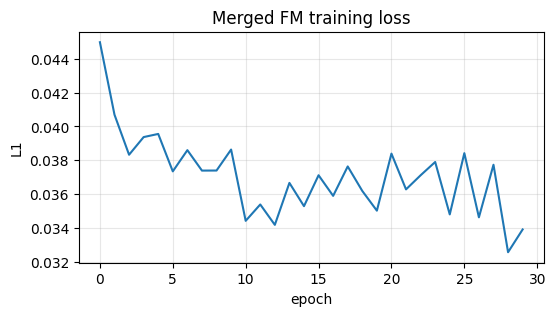

In [32]:
# Train merged model on a mixture of (tetris, RGB rectangles)
merged_encoder.train()
merged_fm.train()

optimizer = torch.optim.AdamW(list(merged_encoder.parameters()) + list(merged_fm.parameters()), lr=MERGED_LR)

train_losses = []

for epoch in range(MERGED_EPOCHS):
    epoch_loss = 0.0

    for _ in tqdm(range(MERGED_STEPS_PER_EPOCH), desc=f"epoch {epoch+1}/{MERGED_EPOCHS}"):
        use_tetris = (random.random() < P_MIX_TETRIS)

        if use_tetris:
            base_gray, dino_emb = sample_tetris_batch(MERGED_BATCH_SIZE)  # gray in [-1,1]
            base_rgb = ((base_gray + 1.0) * 0.5).repeat(1, 3, 1, 1).clamp(0.0, 1.0)
        else:
            base_rgb = sample_color_batch(MERGED_BATCH_SIZE)
            dino_emb = torch.zeros((MERGED_BATCH_SIZE, 384), device=device)

        color_emb = merged_encoder(base_rgb)

        B = base_rgb.shape[0]
        ang_start = torch.rand(B, device=device) * 360.0
        ang_delta = torch.rand(B, device=device) * 360.0 - 180.0
        t = torch.rand(B, 1, device=device)

        ang_t = ang_start + (t.squeeze(1) * ang_delta)
        x_t = KG.rotate(base_rgb, ang_t)

        ang_next = ang_t + (MERGED_DT * ang_delta)
        x_next = KG.rotate(base_rgb, ang_next)

        target_v = (x_next - x_t) / MERGED_DT
        pred_v = merged_fm(x_t, t, dino_emb, color_emb, ang_delta.view(B, 1))

        loss = F.l1_loss(pred_v, target_v)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += float(loss.item())

    avg = epoch_loss / MERGED_STEPS_PER_EPOCH
    train_losses.append(avg)
    print(f"Epoch {epoch+1}: L1={avg:.6f}")

plt.figure(figsize=(6, 3))
plt.plot(train_losses)
plt.title("Merged FM training loss")
plt.xlabel("epoch")
plt.ylabel("L1")
plt.grid(alpha=0.3)
plt.show()

In [33]:
# Evaluate merged FM on the Ganis-Kievit 3D task
merged_encoder.eval()
merged_fm.eval()

@torch.no_grad()
def apply_rotation_fm_merged(model, base_img_rgb01, dino_emb, color_emb, angle_deg, steps=10):
    dt = 1.0 / steps
    curr = base_img_rgb01.clone()
    B = curr.shape[0]
    target_ang = torch.full((B, 1), float(angle_deg), device=curr.device, dtype=curr.dtype)

    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=curr.device, dtype=curr.dtype)
        v1 = model(curr, t, dino_emb, color_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=curr.device, dtype=curr.dtype)
        v2 = model(mid, t2, dino_emb, color_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
        curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=0.0)
        curr = curr.clamp(0.0, 1.0)

    return curr

@torch.no_grad()
def min_error_over_angles_merged(base_gray, base_rgb01, target_rgb01, angles: np.ndarray, steps: int = 10):
    dino_emb = get_dino_embedding(base_gray).squeeze(1)  # (B,384)
    color_emb = merged_encoder(base_rgb01)

    best_err = float("inf")
    best_angle = None

    for ang in angles:
        rot = apply_rotation_fm_merged(merged_fm, base_rgb01, dino_emb, color_emb, float(ang), steps=steps)
        err = torch.mean((rot - target_rgb01) ** 2).item()
        if err < best_err:
            best_err = err
            best_angle = float(ang)

    return best_err, best_angle

@torch.no_grad()
def evaluate_pair_merged(sample: Dict[str, Any], angles: np.ndarray, steps: int = 10) -> Dict[str, Any]:
    base_gray, target_gray = sample_to_tensors(sample, device=device)
    base_rgb, target_rgb = sample_to_rgb01(sample, device=device)

    err_orig, ang_orig = min_error_over_angles_merged(base_gray, base_rgb, target_rgb, angles, steps)

    base_gray_flip = torch.flip(base_gray, dims=[3])
    base_rgb_flip = torch.flip(base_rgb, dims=[3])
    err_flip, ang_flip = min_error_over_angles_merged(base_gray_flip, base_rgb_flip, target_rgb, angles, steps)

    label_same = (sample.get("label") == "same")
    pred_same = err_orig <= err_flip
    score = err_flip - err_orig

    return {
        "err_orig": err_orig,
        "err_flip": err_flip,
        "best_angle": ang_orig,
        "best_angle_flip": ang_flip,
        "label_same": label_same,
        "pred_same": pred_same,
        "score": score,
        "name": sample.get("name"),
        "angle": sample.get("angle"),
    }

results_merged = []
raw_iter = test_raw[:MAX_TEST] if MAX_TEST is not None else test_raw

for sample in tqdm(raw_iter, total=len(raw_iter)):
    results_merged.append(evaluate_pair_merged(sample, ANGLES, steps=FM_STEPS))

labels_m = np.array([1 if r["label_same"] else 0 for r in results_merged], dtype=np.int32)
preds_m = np.array([1 if r["pred_same"] else 0 for r in results_merged], dtype=np.int32)
scores_m = np.array([r["score"] for r in results_merged], dtype=np.float32)

acc_m = accuracy_score(labels_m, preds_m)
auc_m = roc_auc_score(labels_m, scores_m)

print("Merged FM rotation search results")
print("  Accuracy (mirror-vs-rotation rule):", f"{acc_m:.4f}")
print("  AUC (score = err_flip - err_orig):", f"{auc_m:.4f}")

100%|██████████| 78/78 [4:49:34<00:00, 222.75s/it]  

Merged FM rotation search results
  Accuracy (mirror-vs-rotation rule): 0.5641
  AUC (score = err_flip - err_orig): 0.6463


In [34]:
# Summary table
rows = []

# tetris
labels_t = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
score_t = np.array([r["score"] for r in results], dtype=np.float32)
auc_t = roc_auc_score(labels_t, score_t)
acc_t = accuracy_score(labels_t, (score_t > 0).astype(np.int32))  # not the same as the err_orig<=err_flip rule, but comparable thresholded score
rows.append(("tetris_fm", float(acc), float(auc_t)))

# color
labels_c = np.array([1 if r["label_same"] else 0 for r in results_color], dtype=np.int32)
score_c = np.array([r["score"] for r in results_color], dtype=np.float32)
auc_c = roc_auc_score(labels_c, score_c)
acc_c = accuracy_score(labels_c, (score_c > 0).astype(np.int32))
rows.append(("color_fm", float(acc_color), float(auc_c)))

# late fusion
rows.append(("late_fusion", float(acc_late), float(auc_late)))
# scale-only fusion
if 'auc_scale' in globals() and 'acc_scale' in globals():
    rows.append(("scale_fusion", float(acc_scale), float(auc_scale)))

# confidence-vote fusion
if 'auc_conf' in globals() and 'acc_conf' in globals():
    rows.append(("conf_vote", float(acc_conf), float(auc_conf)))


# merged
if 'results_merged' in globals():
    labels_mm = np.array([1 if r["label_same"] else 0 for r in results_merged], dtype=np.int32)
    score_mm = np.array([r["score"] for r in results_merged], dtype=np.float32)
    auc_mm = roc_auc_score(labels_mm, score_mm)
    rows.append(("merged_fm", float(acc_m), float(auc_mm)))



# dev-learned alpha fusion (after running Option 2b)
if 'acc_dev_alpha_auc' in globals() and acc_dev_alpha_auc is not None:
    rows.append(("dev_alpha_auc", float(acc_dev_alpha_auc), float(auc_dev_alpha_auc)))
if 'acc_dev_alpha_acc' in globals() and acc_dev_alpha_acc is not None:
    rows.append(("dev_alpha_acc", float(acc_dev_alpha_acc), float(auc_dev_alpha_acc)))

# per-sample MoE gate (after running Option 2c)
if 'acc_moe_gate' in globals() and acc_moe_gate is not None:
    rows.append(("moe_gate", float(acc_moe_gate), float(auc_moe_gate)))

print("\nModel\t\tAccuracy\tAUC")
for name, a, u in rows:
    print(f"{name:12s}\t{a:.4f}\t\t{u:.4f}")



Model		Accuracy	AUC
tetris_fm   	0.6538		0.6778
color_fm    	0.6026		0.6456
late_fusion 	0.6026		0.6765
merged_fm   	0.5641		0.6463


In [39]:
# Option 2: tiny learned combiner (single alpha) trained on synthetic 2D rotations (no 3D training)
# We learn alpha in [0,1] to combine the two expert scores while preserving the 0-threshold semantics.

import kornia.geometry.transform as KG

# --- config ---
COMBINER_SEED = 0
N_SYNTH_TRAIN = 256
N_SYNTH_VAL = 256
ALPHA_GRID = np.linspace(0.0, 1.0, 51)  # 0.00 .. 1.00
SYNTH_FM_STEPS = 6

rng = np.random.default_rng(COMBINER_SEED)
random.seed(COMBINER_SEED)
torch.manual_seed(COMBINER_SEED)

# Require that both experts are loaded
assert 'fm_model' in globals(), "Run the tetris FM load/eval cells first (fm_model missing)."
assert 'color_fm' in globals() and 'color_encoder' in globals(), "Run the colored FM load/eval cells first (color_fm/color_encoder missing)."

# --- synthetic generators ---
CHIRAL_SHAPES_SYNTH = {
    'L': [(0, -1), (0, 0), (0, 1), (1, 1)],
    'J': [(0, -1), (0, 0), (0, 1), (-1, 1)],
    'S': [(0, 0), (1, 0), (0, 1), (-1, 1)],
    'Z': [(0, 0), (-1, 0), (0, 1), (1, 1)],
    'F': [(0, 0), (0, -1), (1, -1), (-1, 0), (0, 1)],
    'P': [(0, 0), (0, -1), (1, -1), (1, 0), (0, 1)],
}


def draw_tetris_gray(name: str, size: int = 64) -> torch.Tensor:
    """Return (1,1,H,W) in [-1,1]."""
    img = torch.zeros(size, size, dtype=torch.float32)
    center = size // 2
    block = size // 8
    for dx, dy in CHIRAL_SHAPES_SYNTH[name]:
        x0 = center + (dx * block) - (block // 2)
        y0 = center + (dy * block) - (block // 2)
        x1 = x0 + block
        y1 = y0 + block
        img[y0:y1, x0:x1] = 1.0
    img = img.unsqueeze(0).unsqueeze(0)  # (1,1,H,W) in [0,1]
    return img * 2.0 - 1.0


@torch.no_grad()
def random_rgb_rectangles(h: int = 64, w: int = 64, num_shapes: int = 4) -> torch.Tensor:
    img = torch.zeros(3, h, w)
    for _ in range(num_shapes):
        color = torch.rand(3, 1, 1)
        y0 = random.randint(0, h - 8)
        x0 = random.randint(0, w - 8)
        y1 = min(h, y0 + random.randint(6, h // 2))
        x1 = min(w, x0 + random.randint(6, w // 2))
        img[:, y0:y1, x0:x1] = color
    return img


# Precompute DINO embeddings for each tetris shape and its horizontal flip
print("Precomputing DINO embeddings for synthetic tetris shapes...")
TETRIS_KEYS = list(CHIRAL_SHAPES_SYNTH.keys())
TETRIS_EMB = {}
TETRIS_EMB_FLIP = {}

with torch.no_grad():
    for k in TETRIS_KEYS:
        base = draw_tetris_gray(k).to(device)  # (1,1,64,64) [-1,1]
        emb = get_dino_embedding(base)  # (1,384)
        TETRIS_EMB[k] = emb.squeeze(0)

        base_f = torch.flip(base, dims=[3])
        emb_f = get_dino_embedding(base_f)
        TETRIS_EMB_FLIP[k] = emb_f.squeeze(0)


@torch.no_grad()
def score_pair_tetris(base_gray: torch.Tensor, target_gray: torch.Tensor, angle_deg: float) -> float:
    # base_gray/target_gray: (1,1,64,64) in [-1,1]
    # Use DINO embedding of base for the orig hypothesis, and embedding of flipped base for flip hypothesis.
    # (This matches how evaluate_pair() recomputes embedding when flipping.)
    # NOTE: base_gray here is always a tetris shape, so we can use the cached embedding.
    # Find which key it is? We skip and compute embedding directly if not cached.
    emb = get_dino_embedding(base_gray).squeeze(0)

    rot = apply_rotation_fm(fm_model, base_gray, emb.unsqueeze(0), angle_deg, steps=SYNTH_FM_STEPS)
    err_orig = torch.mean((rot - target_gray) ** 2).item()

    base_f = torch.flip(base_gray, dims=[3])
    emb_f = get_dino_embedding(base_f).squeeze(0)
    rot_f = apply_rotation_fm(fm_model, base_f, emb_f.unsqueeze(0), angle_deg, steps=SYNTH_FM_STEPS)
    err_flip = torch.mean((rot_f - target_gray) ** 2).item()

    return float(err_flip - err_orig)


@torch.no_grad()
def score_pair_color(base_rgb01: torch.Tensor, target_rgb01: torch.Tensor, angle_deg: float) -> float:
    # base_rgb01/target_rgb01: (1,3,64,64) in [0,1]
    emb = color_encoder(base_rgb01)
    rot = apply_rotation_fm_rgb(color_fm, base_rgb01, emb, angle_deg, steps=SYNTH_FM_STEPS)
    err_orig = torch.mean((rot - target_rgb01) ** 2).item()

    base_f = torch.flip(base_rgb01, dims=[3])
    emb_f = color_encoder(base_f)
    rot_f = apply_rotation_fm_rgb(color_fm, base_f, emb_f, angle_deg, steps=SYNTH_FM_STEPS)
    err_flip = torch.mean((rot_f - target_rgb01) ** 2).item()

    return float(err_flip - err_orig)


@torch.no_grad()
def make_synth_dataset(n: int):
    s_t, s_c, y = [], [], []

    for _ in tqdm(range(n), desc=f"synth {n}"):
        is_same = (rng.random() < 0.5)
        y.append(1 if is_same else 0)

        # Mix domains 50/50
        if rng.random() < 0.5:
            # tetris domain
            k = random.choice(TETRIS_KEYS)
            base_gray = draw_tetris_gray(k).to(device)
            base_rgb = ((base_gray + 1.0) * 0.5).repeat(1, 3, 1, 1).clamp(0.0, 1.0)
        else:
            # color rectangles domain
            base_rgb = random_rgb_rectangles(64, 64, num_shapes=4).unsqueeze(0).to(device)
            # grayscale for the tetris FM branch
            base_gray = base_rgb[:, :1, :, :] * 2.0 - 1.0

        # Random angle
        angle = float(rng.uniform(-180.0, 180.0))

        if is_same:
            tgt_gray = KG.rotate(base_gray, torch.tensor([angle], device=device))
            tgt_rgb = KG.rotate(base_rgb, torch.tensor([angle], device=device))
        else:
            base_gray_f = torch.flip(base_gray, dims=[3])
            base_rgb_f = torch.flip(base_rgb, dims=[3])
            tgt_gray = KG.rotate(base_gray_f, torch.tensor([angle], device=device))
            tgt_rgb = KG.rotate(base_rgb_f, torch.tensor([angle], device=device))

        # Expert scores
        s_t.append(score_pair_tetris(base_gray, tgt_gray, angle))
        s_c.append(score_pair_color(base_rgb, tgt_rgb, angle))

    return np.array(s_t, dtype=np.float32), np.array(s_c, dtype=np.float32), np.array(y, dtype=np.int32)


s_t_tr, s_c_tr, y_tr = make_synth_dataset(N_SYNTH_TRAIN)
s_t_va, s_c_va, y_va = make_synth_dataset(N_SYNTH_VAL)

std_t = float(np.std(s_t_tr) + 1e-8)
std_c = float(np.std(s_c_tr) + 1e-8)

s_t_trn, s_c_trn = s_t_tr / std_t, s_c_tr / std_c
s_t_van, s_c_van = s_t_va / std_t, s_c_va / std_c


def eval_alpha(alpha: float, s_t: np.ndarray, s_c: np.ndarray, y: np.ndarray):
    fused = alpha * s_t + (1.0 - alpha) * s_c
    acc = accuracy_score(y, (fused >= 0).astype(np.int32))
    auc = roc_auc_score(y, fused)
    return float(acc), float(auc)

best_by_auc = (-1.0, None)
best_by_acc = (-1.0, None)

for a in ALPHA_GRID:
    acc_a, auc_a = eval_alpha(float(a), s_t_van, s_c_van, y_va)
    if auc_a > best_by_auc[0]:
        best_by_auc = (auc_a, float(a))
    if acc_a > best_by_acc[0]:
        best_by_acc = (acc_a, float(a))

print("\nSynthetic validation (no 3D):")
print("  std_tetris:", std_t)
print("  std_color:", std_c)
print("  best alpha by AUC:", best_by_auc[1], "AUC=", f"{best_by_auc[0]:.4f}")
print("  best alpha by Acc:", best_by_acc[1], "Acc=", f"{best_by_acc[0]:.4f}")

# --- Evaluate the learned alpha on the 3D task using the already-computed 3D scores ---
labels_3d = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
score_t_3d = np.array([r["score"] for r in results], dtype=np.float32) / std_t
score_c_3d = np.array([r["score"] for r in results_color], dtype=np.float32) / std_c

for tag, alpha in [("by_auc", best_by_auc[1]), ("by_acc", best_by_acc[1])]:
    fused_3d = alpha * score_t_3d + (1.0 - alpha) * score_c_3d
    acc_3d = accuracy_score(labels_3d, (fused_3d >= 0).astype(np.int32))
    auc_3d = roc_auc_score(labels_3d, fused_3d)

    print(f"\nLearned-alpha fusion on 3D ({tag})")
    print("  alpha:", alpha)
    print("  Accuracy (threshold at 0):", f"{acc_3d:.4f}")
    print("  AUC:", f"{auc_3d:.4f}")


Precomputing DINO embeddings for synthetic tetris shapes...


synth 256: 100%|██████████| 256/256 [01:52<00:00,  2.27it/s]


Synthetic validation (no 3D):
  std_tetris: 0.15506897866725922
  std_color: 0.0440715029835701
  best alpha by AUC: 0.0 AUC= 0.9415
  best alpha by Acc: 0.0 Acc= 0.8633

Learned-alpha fusion on 3D (by_auc)
  alpha: 0.0
  Accuracy (threshold at 0): 0.6026
  AUC: 0.6456

Learned-alpha fusion on 3D (by_acc)
  alpha: 0.0
  Accuracy (threshold at 0): 0.6026
  AUC: 0.6456


In [41]:
# Option 2b: learn alpha on a held-out 3D *dev* split (same scoring procedure; no test tuning)
# This uses labeled 3D dev data ONLY to fit the scalar alpha, then evaluates once on the fixed 3D test set.
# NOTE: this is NOT a per-sample MoE gate; it's a single global alpha.

import os
import glob
from pathlib import Path
import cv2

DEV_SEED = 0
# total dev size = 2 * N_DEV_PER_CLASS (same + diff)
N_DEV_PER_CLASS = 40  # total dev size = 80
DEV_ALPHA_GRID = np.linspace(0.0, 1.0, 101)

GANIS_DIR = "data/ganis_kievit_data/stimuli_jpgs"
DEV_CACHE_PATH = Path(f"logs/pipeline_3d_dev_cache_seed{DEV_SEED}_n{N_DEV_PER_CLASS}.npz")
DEV_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

# --- build (or load) a balanced dev set disjoint from test_balanced.npy ---
# same pool: train_raw (all same images not in test)
# diff pool: all *_R.jpg excluding those already in test

# Helper: process raw jpgs like scripts/prep_ganis_kievit.py
OUTPUT_SIZE = (64, 64)

def process_ganis_file(f_path: str):
    filename = Path(f_path).stem
    parts = filename.split('_')
    angle = int(parts[1])
    label_name = 'diff'

    img = cv2.imread(f_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f_path)

    h, w = img.shape
    img_left = img[:, :w // 2]
    img_right = img[:, w // 2:]

    x0 = cv2.resize(img_left, OUTPUT_SIZE)
    x1 = cv2.resize(img_right, OUTPUT_SIZE)

    x0 = (x0.astype(np.float32) / 127.5) - 1.0
    x1 = (x1.astype(np.float32) / 127.5) - 1.0

    return {
        'x0': np.expand_dims(x0, axis=0),
        'x1': np.expand_dims(x1, axis=0),
        'angle': angle,
        'name': filename,
        'label': label_name,
    }


if DEV_CACHE_PATH.exists():
    cache = np.load(DEV_CACHE_PATH, allow_pickle=True)
    labels_dev = cache["labels_dev"].astype(np.int32)
    score_t_dev = cache["score_t_dev"].astype(np.float32)
    score_c_dev = cache["score_c_dev"].astype(np.float32)
    err_orig_t_dev = cache["err_orig_t_dev"].astype(np.float32)
    err_flip_t_dev = cache["err_flip_t_dev"].astype(np.float32)
    err_orig_c_dev = cache["err_orig_c_dev"].astype(np.float32)
    err_flip_c_dev = cache["err_flip_c_dev"].astype(np.float32)
    dev_names = cache["dev_names"] if "dev_names" in cache.files else None
    print(f"Loaded cached dev scores: {DEV_CACHE_PATH} (n={len(labels_dev)})")
else:
    test_names = set([d.get('name') for d in test_raw])

    same_pool = list(train_raw)  # dicts already processed to x0/x1 in [-1,1]

    diff_paths = sorted(glob.glob(os.path.join(GANIS_DIR, "*_R.jpg")))
    diff_paths = [p for p in diff_paths if Path(p).stem not in test_names]

    if N_DEV_PER_CLASS > len(same_pool):
        raise ValueError(f"N_DEV_PER_CLASS={N_DEV_PER_CLASS} > same_pool={len(same_pool)}")
    if N_DEV_PER_CLASS > len(diff_paths):
        raise ValueError(f"N_DEV_PER_CLASS={N_DEV_PER_CLASS} > diff_pool={len(diff_paths)}")

    rng = np.random.default_rng(DEV_SEED)

    same_idx = rng.choice(len(same_pool), size=N_DEV_PER_CLASS, replace=False)
    dev_same = [same_pool[int(i)] for i in same_idx]

    diff_sel = rng.choice(diff_paths, size=N_DEV_PER_CLASS, replace=False)
    dev_diff = [process_ganis_file(str(p)) for p in diff_sel]

    dev_raw = dev_same + dev_diff
    rng.shuffle(dev_raw)

    print(
        f"Dev set size: {len(dev_raw)} ({N_DEV_PER_CLASS} same from train_raw + {N_DEV_PER_CLASS} diff from unused) seed={DEV_SEED}"
    )

    # --- compute expert scores on dev (same scoring as test: min-over-angles, compare orig vs flip) ---
    results_dev = []
    results_dev_color = []

    for sample in tqdm(dev_raw, total=len(dev_raw), desc="dev tetris_fm"):
        results_dev.append(evaluate_pair(sample, ANGLES, steps=FM_STEPS))

    for sample in tqdm(dev_raw, total=len(dev_raw), desc="dev color_fm"):
        results_dev_color.append(evaluate_pair_rgb(sample, ANGLES, steps=FM_STEPS))

    labels_dev = np.array([1 if r["label_same"] else 0 for r in results_dev], dtype=np.int32)

    score_t_dev = np.array([r["score"] for r in results_dev], dtype=np.float32)
    err_orig_t_dev = np.array([r["err_orig"] for r in results_dev], dtype=np.float32)
    err_flip_t_dev = np.array([r["err_flip"] for r in results_dev], dtype=np.float32)

    score_c_dev = np.array([r["score"] for r in results_dev_color], dtype=np.float32)
    err_orig_c_dev = np.array([r["err_orig"] for r in results_dev_color], dtype=np.float32)
    err_flip_c_dev = np.array([r["err_flip"] for r in results_dev_color], dtype=np.float32)

    dev_names = np.array([r.get("name") for r in results_dev], dtype=object)

    np.savez(
        DEV_CACHE_PATH,
        labels_dev=labels_dev,
        score_t_dev=score_t_dev,
        score_c_dev=score_c_dev,
        err_orig_t_dev=err_orig_t_dev,
        err_flip_t_dev=err_flip_t_dev,
        err_orig_c_dev=err_orig_c_dev,
        err_flip_c_dev=err_flip_c_dev,
        dev_names=dev_names,
    )
    print(f"Saved dev cache: {DEV_CACHE_PATH}")

# --- dev expert sanity ---
acc_t_dev = accuracy_score(labels_dev, (score_t_dev >= 0).astype(np.int32))
acc_c_dev = accuracy_score(labels_dev, (score_c_dev >= 0).astype(np.int32))
auc_t_dev = roc_auc_score(labels_dev, score_t_dev)
auc_c_dev = roc_auc_score(labels_dev, score_c_dev)

print("\nDev expert performance")
print("  tetris_fm  acc:", f"{acc_t_dev:.4f}", "auc:", f"{auc_t_dev:.4f}")
print("  color_fm   acc:", f"{acc_c_dev:.4f}", "auc:", f"{auc_c_dev:.4f}")

# --- Fit scalar alpha on dev (scale-only normalization; no mean-centering) ---
std_t_dev = float(np.std(score_t_dev) + 1e-8)
std_c_dev = float(np.std(score_c_dev) + 1e-8)

st = score_t_dev / std_t_dev
sc = score_c_dev / std_c_dev

best_auc = (-1.0, None)
best_acc = (-1.0, None)

for a in DEV_ALPHA_GRID:
    fused = float(a) * st + (1.0 - float(a)) * sc
    auc = roc_auc_score(labels_dev, fused)
    acc = accuracy_score(labels_dev, (fused >= 0).astype(np.int32))

    # Tie-break: prefer larger alpha (more tetris) for stability.
    if (auc > best_auc[0]) or (auc == best_auc[0] and (best_auc[1] is None or float(a) > float(best_auc[1]))):
        best_auc = (float(auc), float(a))
    if (acc > best_acc[0]) or (acc == best_acc[0] and (best_acc[1] is None or float(a) > float(best_acc[1]))):
        best_acc = (float(acc), float(a))

alpha_dev_auc = best_auc[1]
alpha_dev_acc = best_acc[1]

print("\nDev-selected alpha (no test tuning):")
print("  std_t_dev:", std_t_dev)
print("  std_c_dev:", std_c_dev)
print("  best alpha by dev AUC:", alpha_dev_auc, "dev AUC=", f"{best_auc[0]:.4f}")
print("  best alpha by dev Acc:", alpha_dev_acc, "dev Acc=", f"{best_acc[0]:.4f}")

# --- evaluate once on the fixed test set using the same scaling from dev ---
labels_test = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
score_t_test = np.array([r["score"] for r in results], dtype=np.float32) / std_t_dev
score_c_test = np.array([r["score"] for r in results_color], dtype=np.float32) / std_c_dev

acc_dev_alpha_auc = auc_dev_alpha_auc = None
acc_dev_alpha_acc = auc_dev_alpha_acc = None

for tag, alpha in [("by_dev_auc", alpha_dev_auc), ("by_dev_acc", alpha_dev_acc)]:
    fused_test = float(alpha) * score_t_test + (1.0 - float(alpha)) * score_c_test
    auc = roc_auc_score(labels_test, fused_test)
    acc = accuracy_score(labels_test, (fused_test >= 0).astype(np.int32))
    print(f"\nDev-learned alpha fusion on TEST ({tag})")
    print("  alpha:", alpha)
    print("  Accuracy (threshold at 0):", f"{acc:.4f}")
    print("  AUC:", f"{auc:.4f}")

    if tag == "by_dev_auc":
        acc_dev_alpha_auc = float(acc)
        auc_dev_alpha_auc = float(auc)
    else:
        acc_dev_alpha_acc = float(acc)
        auc_dev_alpha_acc = float(auc)


Dev set size: 80 (40 same from train_raw + 40 diff from unused) seed=0


dev color_fm: 100%|██████████| 80/80 [18:07<00:00, 13.60s/it]

Saved dev cache: logs/pipeline_3d_dev_cache_seed0_n40.npz

Dev expert performance
  tetris_fm  acc: 0.5875 auc: 0.6569
  color_fm   acc: 0.6250 auc: 0.6750

Dev-selected alpha (no test tuning):
  std_t_dev: 0.29813283681869507
  std_c_dev: 0.025691142305731773
  best alpha by dev AUC: 0.37 dev AUC= 0.7038
  best alpha by dev Acc: 0.42 dev Acc= 0.6500

Dev-learned alpha fusion on TEST (by_dev_auc)
  alpha: 0.37
  Accuracy (threshold at 0): 0.6026
  AUC: 0.6515

Dev-learned alpha fusion on TEST (by_dev_acc)
  alpha: 0.42
  Accuracy (threshold at 0): 0.6154
  AUC: 0.6568


In [42]:
# Option 2c: per-sample MoE gate (dev-tuned, test-once)
# Goal: actually behave like an MoE: choose *which expert* to trust per sample.
# We tune a single gate threshold on dev, and default to the stronger expert (tetris) when unsure.

# Requires Option 2b to have run (or loaded cache) so we have dev arrays.
required = [
    'labels_dev',
    'score_t_dev', 'score_c_dev',
    'err_orig_t_dev', 'err_flip_t_dev',
    'err_orig_c_dev', 'err_flip_c_dev',
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing dev variables: {missing}. Run the Option 2b cell first.")

labels_test = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)

# Expert predictions on dev/test (0-threshold semantics)
pred_t_dev = (score_t_dev >= 0).astype(np.int32)
pred_c_dev = (score_c_dev >= 0).astype(np.int32)

score_t_test_raw = np.array([r["score"] for r in results], dtype=np.float32)
score_c_test_raw = np.array([r["score"] for r in results_color], dtype=np.float32)

pred_t_test = (score_t_test_raw >= 0).astype(np.int32)
pred_c_test = (score_c_test_raw >= 0).astype(np.int32)

# Confidence heuristic (dimensionless): margin / best_error.
# margin = |err_flip - err_orig|, best_error = min(err_orig, err_flip)
# Intuition: a model is confident if it both (a) clearly prefers orig vs flip and (b) can actually match one hypothesis well.
EPS = 1e-8

minerr_t_dev = np.minimum(err_orig_t_dev, err_flip_t_dev)
minerr_c_dev = np.minimum(err_orig_c_dev, err_flip_c_dev)

conf_t_dev = np.abs(score_t_dev) / (minerr_t_dev + EPS)
conf_c_dev = np.abs(score_c_dev) / (minerr_c_dev + EPS)

logratio_dev = np.log(conf_c_dev + EPS) - np.log(conf_t_dev + EPS)  # >0 => color more confident

# Sweep thresholds where decisions change (quantile grid) + endpoints.
q = np.linspace(0.0, 1.0, 401)
th_grid = np.unique(np.concatenate(([-np.inf], np.quantile(logratio_dev, q), [np.inf])))

best = (-1.0, None, None)  # (acc, thresh, frac_color)

for th in th_grid:
    use_color = logratio_dev > th
    pred = np.where(use_color, pred_c_dev, pred_t_dev)
    acc = float(np.mean(pred == labels_dev))
    frac = float(np.mean(use_color))

    # Maximize dev accuracy; tie-break in favor of *fewer* color selections (more conservative, closer to tetris).
    if (acc > best[0]) or (acc == best[0] and (best[2] is None or frac < best[2])):
        best = (acc, float(th), frac)

best_acc_dev, gate_th, frac_color_dev = best

print("\nMoE gate tuned on DEV")
print("  dev acc(tetris):", f"{accuracy_score(labels_dev, pred_t_dev):.4f}")
print("  dev acc(color): ", f"{accuracy_score(labels_dev, pred_c_dev):.4f}")
print("  best dev acc(gated):", f"{best_acc_dev:.4f}")
print("  gate threshold (log conf ratio):", gate_th)
print("  frac choose color on dev:", f"{frac_color_dev:.3f}")

# --- Apply to TEST once ---
err_orig_t_test = np.array([r["err_orig"] for r in results], dtype=np.float32)
err_flip_t_test = np.array([r["err_flip"] for r in results], dtype=np.float32)
err_orig_c_test = np.array([r["err_orig"] for r in results_color], dtype=np.float32)
err_flip_c_test = np.array([r["err_flip"] for r in results_color], dtype=np.float32)

minerr_t_test = np.minimum(err_orig_t_test, err_flip_t_test)
minerr_c_test = np.minimum(err_orig_c_test, err_flip_c_test)

conf_t_test = np.abs(score_t_test_raw) / (minerr_t_test + EPS)
conf_c_test = np.abs(score_c_test_raw) / (minerr_c_test + EPS)
logratio_test = np.log(conf_c_test + EPS) - np.log(conf_t_test + EPS)

use_color_test = logratio_test > gate_th
pred_gate_test = np.where(use_color_test, pred_c_test, pred_t_test)

acc_gate = float(np.mean(pred_gate_test == labels_test))
frac_color_test = float(np.mean(use_color_test))

# AUC with per-sample selected (dev-standardized) score
# (use the dev stds to roughly put them on comparable scales)
score_t_test_std = score_t_test_raw / (float(np.std(score_t_dev)) + EPS)
score_c_test_std = score_c_test_raw / (float(np.std(score_c_dev)) + EPS)
score_gate = np.where(use_color_test, score_c_test_std, score_t_test_std)
auc_gate = float(roc_auc_score(labels_test, score_gate))

# Oracle upper bound (if we could always pick the correct expert)
correct_t = (pred_t_test == labels_test)
correct_c = (pred_c_test == labels_test)
oracle_pred = np.where(correct_t, pred_t_test, pred_c_test)
oracle_acc = float(np.mean(oracle_pred == labels_test))

print("\nMoE gate on TEST")
print("  Accuracy:", f"{acc_gate:.4f}")
print("  AUC (selected expert score):", f"{auc_gate:.4f}")
print("  frac choose color on test:", f"{frac_color_test:.3f}")
print("\nOracle MoE upper bound on TEST")
print("  oracle acc:", f"{oracle_acc:.4f}")
print("  both wrong:", int(np.sum(~correct_t & ~correct_c)), "/", int(len(labels_test)))

# expose for summary (rerun summary cell after this if desired)
acc_moe_gate = acc_gate
auc_moe_gate = auc_gate
moe_gate_th = gate_th



MoE gate tuned on DEV
  dev acc(tetris): 0.5875
  dev acc(color):  0.6250
  best dev acc(gated): 0.6500
  gate threshold (log conf ratio): -1.171495209336281
  frac choose color on dev: 0.500

MoE gate on TEST
  Accuracy: 0.6026
  AUC (selected expert score): 0.6410
  frac choose color on test: 0.590

Oracle MoE upper bound on TEST
  oracle acc: 0.8590
  both wrong: 11 / 78
